# Heat-Transfer Coefficients: From Correlations to `U` to an Optimal Velocity

The exchangers take `U` or `UA` as an input. `difflow.heat_transfer` computes it from geometry, flow and fluid
properties, and everything is differentiable. This notebook

1. computes the tube-side film coefficient of water across laminar, transition and turbulent flow (`internal_h`),
2. builds an overall `U` with fouling (`overall_U`) and feeds it to `CounterCurrentHX`,
3. shows the phase-change correlations (condensation, Rohsenow boiling, Zuber peak flux),
4. finds the **economically optimal tube velocity** with `jax.grad` and `difflow.economics`.

**What is and is not validated.** The correlations are checked against independent evaluations of their stated
formulas and, where a derivation exists, against it (see `tests/test_heat_transfer.py`). No textbook worked-example
number is reproduced. **All prices and the shell-side coefficient used in section 4 are illustrative placeholders,
not data**; the method, not the dollar figure, is the point. The tabulated fouling resistances and typical `U`
ranges in the module are transcribed from memory and flagged as such.

In [1]:
import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)

from difflow import heat_transfer as ht, CounterCurrentHX, HeatExchangerParams, make_stream
from difflow.fluids import friction_factor
import difflow.economics as econ

## 1. Tube-side film coefficient across the transition

Water near 40 C (property values are inputs; core `SpeciesData` has no liquid transport properties).
`internal_h` is continuous and differentiable through the blend between Re = 2300 and 4000, with no Python
branching on `Re`.

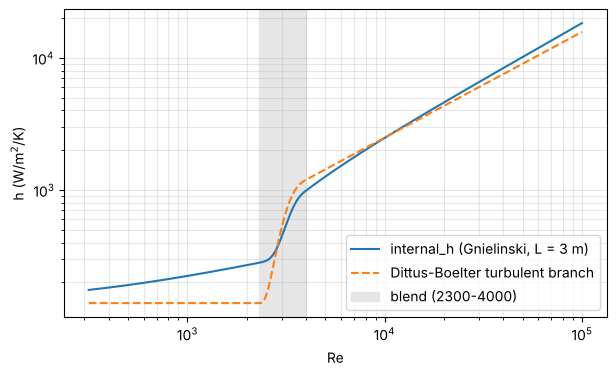

finite gradients everywhere: True | non-negative: True


In [2]:
rho, mu, Cp, k = 992.0, 653e-6, 4179.0, 0.631      # water, ~40 C
Pr = ht.prandtl(Cp, mu, k)
D_i = 0.0166

Re = jnp.logspace(2.5, 5, 400)
h = jax.vmap(lambda r: ht.internal_h(r, Pr, k, D_i, L=3.0))(Re)
h_gn = jax.vmap(lambda r: ht.internal_h(r, Pr, k, D_i, method="gnielinski"))(Re)
h_db = jax.vmap(lambda r: ht.internal_h(r, Pr, k, D_i, method="dittus_boelter"))(Re)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(Re, h, label="internal_h (Gnielinski, L = 3 m)")
ax.loglog(Re, h_db, "--", label="Dittus-Boelter turbulent branch")
ax.axvspan(2300, 4000, color="0.9", label="blend (2300-4000)")
ax.set_xlabel("Re"); ax.set_ylabel("h (W/m$^2$/K)"); ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.show()

# gradient of h with respect to Re is finite everywhere, including the blend
dh = jax.vmap(jax.grad(lambda r: ht.internal_h(r, Pr, k, D_i, L=3.0)))(Re)
print("finite gradients everywhere:", bool(jnp.all(jnp.isfinite(dh))), "| non-negative:", bool(jnp.all(dh >= -1e-9)))

## 2. Overall `U`, then the exchanger

Water (tube side, 1.5 m/s) in a 19.1 mm OD tube bundle, a fixed shell-side coefficient standing in for the shell
fluid, and fouling on both sides. `overall_U` references the outer area; the check `U_o A_o = U_i A_i` holds.

In [3]:
D_o, k_wall = 0.0191, 16.0
h_shell = 600.0                      # illustrative shell-side film coefficient, W/m2/K
R_fi, R_fo = 1.0e-4, 2.0e-4          # illustrative fouling resistances, m2K/W

def U_outer(v, D_i=D_i, basis="outer"):
    Re = ht.reynolds(rho, v, D_i, mu)
    h_i = ht.internal_h(Re, Pr, k, D_i)
    return ht.overall_U(h_i, h_shell, D_i, D_i + (D_o - 0.0166), k_wall, R_fi=R_fi, R_fo=R_fo, basis=basis)

v = 1.5
Uo, Ui = U_outer(v), U_outer(v, basis="inner")
Re_v = ht.reynolds(rho, v, D_i, mu)
print(f"Re = {float(Re_v):.0f}, h_i = {float(ht.internal_h(Re_v, Pr, k, D_i)):.0f} W/m2/K")
print(f"U_outer = {float(Uo):.1f}, U_inner = {float(Ui):.1f};  U_o*D_o = {float(Uo*D_o):.5f}  U_i*D_i = {float(Ui*D_i):.5f}")
print("typical water-to-water band (recalled, unverified):", ht.typical_U_range("water_to_water"),
      "-> U here is below it because the placeholder shell film (600) and the fouling dominate the resistance")
print(f"dU/dv at {v} m/s = {float(jax.grad(U_outer)(v)):.1f} (W/m2/K)/(m/s)")

Re = 37827, h_i = 7988 W/m2/K
U_outer = 452.6, U_inner = 520.8;  U_o*D_o = 8.64447  U_i*D_i = 8.64447
typical water-to-water band (recalled, unverified): (850.0, 1700.0) -> U here is below it because the placeholder shell film (600) and the fouling dominate the resistance


dU/dv at 1.5 m/s = 16.9 (W/m2/K)/(m/s)


In [4]:
# 60 tubes, 4 m long; cold water in the tubes, hot water on the shell side (counter-current)
n_tubes, L = 60, 4.0
A_o = n_tubes * np.pi * D_o * L
UA = float(Uo) * A_o

hot  = make_stream({"water": 800.0}, T=370.0, P=3e5)       # shell side, mol/s
m_tube = n_tubes * np.pi * D_i**2 / 4 * v * rho            # kg/s through the tubes
cold = make_stream({"water": m_tube / 0.018015}, T=300.0, P=3e5)

hx = CounterCurrentHX(HeatExchangerParams(UA=UA, Cp_hot=75.3, Cp_cold=75.3))
hot_out, cold_out, info = hx(hot, cold)
print(f"A = {A_o:.1f} m2, UA = {UA:.0f} W/K, Q = {float(info['Q'])/1e3:.1f} kW, "
      f"T_hot_out = {float(info['T_hot_out']):.1f} K, T_cold_out = {float(info['T_cold_out']):.1f} K")
print(f"check Q = UA*LMTD: {UA*float(info['LMTD'])/1e3:.1f} kW")

A = 14.4 m2, UA = 6518 W/K, Q = 416.8 kW, T_hot_out = 363.1 K, T_cold_out = 305.2 K
check Q = UA*LMTD: 416.9 kW


The exchangers still take a number (a callable `U(hot, cold, params)` is not implemented); because `U` is a
differentiable function of velocity and diameter, the duty is too:

In [5]:
def Q_of_v(v):
    m = n_tubes * np.pi * D_i**2 / 4 * v * rho
    c = make_stream({"water": m / 0.018015}, T=300.0, P=3e5)
    return hx(hot, c, UA=U_outer(v) * A_o)[2]["Q"]

print("dQ/dv =", float(jax.grad(Q_of_v)(1.5)), "W per m/s")

dQ/dv = 24352.986984825788 W per m/s


## 3. Phase change

Steam condensing on a horizontal tube (Nusselt, with the 0.68 Cp subcooling correction), and Rohsenow boiling of
water with the Zuber peak flux. Water-at-100 C properties are inputs.

In [6]:
h_cond = ht.nusselt_film_condensation(k_l=0.68, rho_l=957.9, rho_v=0.5955, mu_l=279e-6, h_fg=2257e3,
                                      Cp_l=4217.0, dT=10.0, L=0.0254)
print(f"steam on a 25.4 mm horizontal tube, dT = 10 K:  h = {float(h_cond):.0f} W/m2/K")
h_bank = ht.nusselt_film_condensation(k_l=0.68, rho_l=957.9, rho_v=0.5955, mu_l=279e-6, h_fg=2257e3,
                                      Cp_l=4217.0, dT=10.0, L=0.0254, n_tubes=10)
print(f"same, 10 tubes in a vertical column:             h = {float(h_bank):.0f} W/m2/K  (x 10^-1/4)")

water = dict(mu_l=279e-6, h_fg=2257e3, rho_l=957.9, rho_v=0.5955, sigma=58.9e-3, Cp_l=4217.0, Pr_l=1.76)
q = 1.0e5
dTe = ht.rohsenow_superheat(q, **water)
print(f"Rohsenow, q = {q:.0e} W/m2:  excess T = {float(dTe):.1f} K, h = {q/float(dTe):.0f} W/m2/K "
      f"(Mostinski: {float(ht.mostinski(q, 22064.0, 101.325)):.0f})")
print(f"Zuber critical heat flux = {float(ht.critical_heat_flux(2257e3, 0.5955, 957.9, 58.9e-3))/1e6:.2f} MW/m2")

steam on a 25.4 mm horizontal tube, dT = 10 K:  h = 12669 W/m2/K
same, 10 tubes in a vertical column:             h = 7124 W/m2/K  (x 10^-1/4)
Rohsenow, q = 1e+05 W/m2:  excess T = 9.0 K, h = 11104 W/m2/K (Mostinski: 9525)
Zuber critical heat flux = 1.11 MW/m2


## 4. Optimal tube velocity

Raising the tube velocity raises `U` (smaller, cheaper exchanger) and the pressure drop (more pumping power).
For a fixed duty the total annualized cost has a minimum. We build the whole chain from the correlations:

* tube count from the flow and the velocity, `U(v)` from `internal_h` and `overall_U`,
* required area `A = Q / (U dT_lm)`, hence the tube length,
* pressure drop from `difflow.fluids.friction_factor` plus an end-loss allowance, pumping power,
* `difflow.economics`: purchased cost (`heat_exchanger_cost`), Lang-factor installation, annualization
  (`annualized_cost`) and electricity (`electricity_cost`).

**The duty, temperature difference, shell-side coefficient, electricity price, plant life and discount rate below are
illustrative placeholders chosen to make the trade-off visible. The result is not a design.**

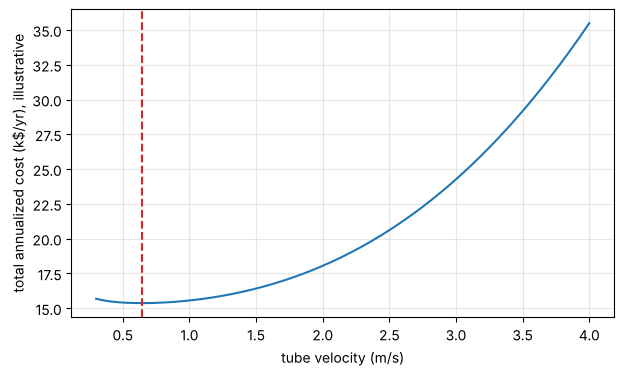

optimal velocity = 0.64 m/s, TAC = 15.4 k$/yr, dTAC/dv = 8.53e-14
grid minimum at v = 0.63 m/s (consistent with the gradient root)


In [7]:
# ---- illustrative placeholders -------------------------------------------------
Q_duty   = 2.0e6        # W
dT_lm    = 30.0         # K
m_water  = 25.0         # kg/s through the tubes
eta_pump = 0.70
hours    = 8000.0       # h/yr
prices   = econ.UtilityPrices(electricity=0.10)    # $/kWh, illustrative (library default is 0.07)
rate, life = 0.10, 15
# --------------------------------------------------------------------------------

def tac(v, D_i=D_i):
    D_o_ = D_i + 0.0025
    N = m_water / (rho * v * jnp.pi * D_i**2 / 4)                    # tubes in parallel
    Re = ht.reynolds(rho, v, D_i, mu)
    U = ht.overall_U(ht.internal_h(Re, Pr, k, D_i), h_shell, D_i, D_o_, k_wall, R_fi=R_fi, R_fo=R_fo)
    A = Q_duty / (U * dT_lm)
    L_tube = A / (N * jnp.pi * D_o_)
    f = friction_factor(Re, 0.0)
    dP = (f * L_tube / D_i + 2.5) * 0.5 * rho * v**2                 # friction + 2.5 velocity heads of end losses
    P_kW = m_water / rho * dP / eta_pump / 1e3
    capex = econ.installed_cost(econ.heat_exchanger_cost(A, "shell_tube_floating"))
    opex = econ.electricity_cost(P_kW, prices) * hours
    return econ.annualized_cost(capex, opex, rate, life)

vs = jnp.linspace(0.3, 4.0, 200)
T = jax.vmap(tac)(vs)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(vs, T / 1e3); ax.set_xlabel("tube velocity (m/s)"); ax.set_ylabel("total annualized cost (k$/yr), illustrative")
ax.grid(alpha=0.3)

# optimum: root of d(TAC)/dv by bisection on the exact gradient
g = jax.grad(tac)
lo, hi = 0.5, 3.5
for _ in range(60):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if g(mid) < 0 else (lo, mid)
v_opt = 0.5 * (lo + hi)
ax.axvline(v_opt, color="C3", ls="--"); plt.show()
print(f"optimal velocity = {v_opt:.2f} m/s, TAC = {float(tac(v_opt))/1e3:.1f} k$/yr, dTAC/dv = {float(g(v_opt)):.2e}")
print(f"grid minimum at v = {float(vs[jnp.argmin(T)]):.2f} m/s (consistent with the gradient root)")

The same chain differentiates with respect to the tube diameter (`jax.grad(tac, argnums=1)`), so velocity and
diameter can be optimized together with any gradient-based optimizer; and because `U` is just a function, a
sensitivity such as `dTAC/dh_shell` is one more `jax.grad` away.

In [8]:
dv, dD = jax.grad(tac, argnums=(0, 1))(float(v_opt), D_i)
print(f"at the optimum: dTAC/dv = {float(dv):.2e}, dTAC/dD_i = {float(dD):.3e} $/yr per m")

at the optimum: dTAC/dv = 8.53e-14, dTAC/dD_i = -3.371e+03 $/yr per m
